# EDA Part 1 (ml.m5.2xlarge)

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func

### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'

str_id = 'uniqueid__app'
str_datecol = 'applicationdate__app'
str_variant = 'noPTImodel10'

list_cols_id = [
#     str_id,
#     str_datecol,
#     'yhat_ad',
#     'yhat_pricing_pd',
#     'yhat_pricing_lgd',
#     'pricing_ecnl',
]

Project: 20231010-gen-xii
Step: 02_eda


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [4]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import data

In [5]:
%%time

# import
str_filename = 'df_retro_predictions.gzip'
str_uri = f's3://{str_project}/08_retro_scoring/07_analysis/{str_variant}/{str_filename}'
# read from s3
df = pd.read_parquet(str_uri)

# show
df

CPU times: user 4.2 s, sys: 1.46 s, total: 5.65 s
Wall time: 1.45 s


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_ad,yhat_pricing_pd,yhat_pricing_lgd
0,0__0__20210120,14.0,stanley,virginia,22851,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.09,1.269231,5.0,9.567123,0.454956,0.457796,0.637971
1,0__0__20210120,14.0,austin,texas,78727,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.12,1.153846,0.0,8.260274,0.533774,0.384922,0.643923
2,0__0__20210122,14.0,stockton,california,95207,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.12,1.215686,3.0,0.547945,0.164688,0.132439,0.634524
3,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.06,1.250000,4.0,4.186301,0.527373,0.294455,0.645909
4,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.15,1.250000,4.0,4.186301,0.587717,0.501850,0.660393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71184,0__0__20231109,5.0,foresthill,texas,76119,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.464286,7.0,15.726027,0.195260,0.200474,0.685285
71185,0__0__20231120,5.0,chicago,illinois,60629,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.269231,6.0,10.542466,0.216180,0.320133,0.687840
71186,0__0__20231107,1.0,pikesville,maryland,21208,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.03,1.034483,3.0,0.512329,0.088405,0.053891,0.606810
71187,0__0__20231117,5.0,saginaw,michigan,48601,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.250000,5.0,6.312329,0.496780,0.318006,0.776057


### Get descriptives

In [6]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=f'{str_dirname_output}/{str_variant}', 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 2021/2021 [00:14<00:00, 138.91it/s]


CPU times: user 14.8 s, sys: 326 ms, total: 15.1 s
Wall time: 15 s


### Get descriptives by ID columns

In [7]:
%%time

try:
    str_filename = 'df_descriptives_id.csv',
    df_tmp = func.get_descriptives_by_column(
        df=df[list_cols_id], 
        str_dirname_output=f'{str_dirname_output}/{str_variant}', 
        str_filename=str_filename,
    )
    # show
    df_tmp
    # save memory
    del df_tmp
except ValueError:
    pass

0it [00:00, ?it/s]

CPU times: user 3.88 ms, sys: 0 ns, total: 3.88 ms
Wall time: 2.93 ms


### Plot proportion ```NaN```

CPU times: user 386 ms, sys: 24.1 ms, total: 410 ms
Wall time: 428 ms


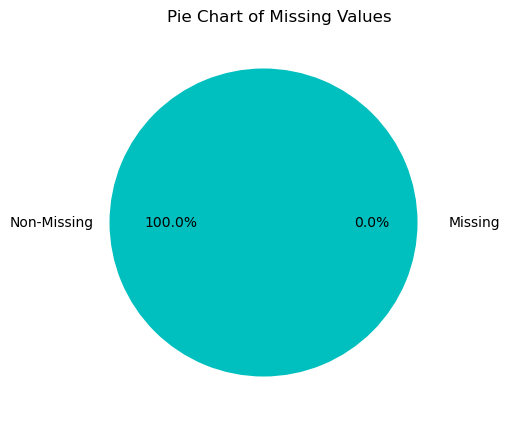

In [8]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=f'{str_dirname_output}/{str_variant}',
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|██████████| 2021/2021 [00:00<00:00, 22462.18it/s]


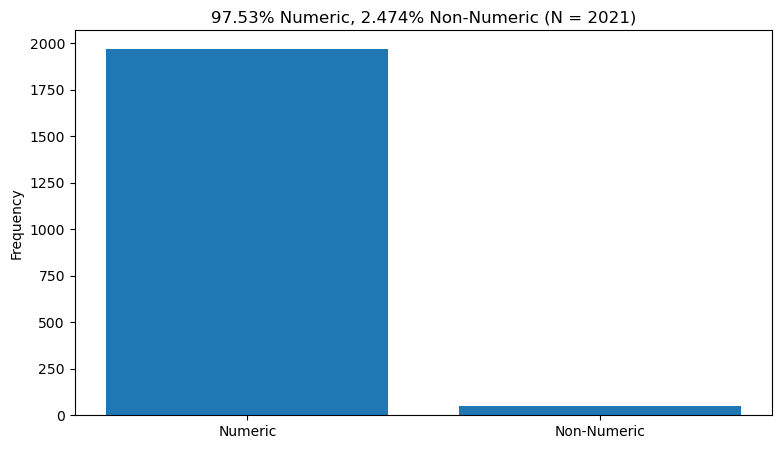

CPU times: user 364 ms, sys: 7.6 ms, total: 372 ms
Wall time: 370 ms


In [9]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=f'{str_dirname_output}/{str_variant}',
    str_filename=str_filename,
)